In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import seaborn as sns

import argparse
from pathlib import Path

In [10]:
def create_calibration_plot(y_true, y_prob, n_bins=100, title="Calibration Plot", save_path=None):
    """
    Create a calibration plot (reliability diagram) for binary classification.
    
    Parameters:
    -----------
    y_true : array-like
        True binary labels (0 or 1)
    y_prob : array-like
        Predicted probabilities for the positive class
    n_bins : int
        Number of bins to use for calibration
    title : str
        Title for the plot
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    dict : Dictionary containing calibration metrics
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_auc_score, log_loss
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    # Calculate Brier score
    brier_score = np.mean((y_prob - y_true) ** 2)
    
    # Calculate AUC-ROC and Log Loss
    auc_score = roc_auc_score(y_true, y_prob)
    log_loss_value = log_loss(y_true, y_prob)
    
    # Manual calibration calculation
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_true_fractions = []
    bin_pred_means = []
    bin_counts = []
    
    # Calculate Expected Calibration Error (ECE)
    ece = 0
    for i in range(n_bins):
        # Create mask for current bin
        if i == n_bins - 1:  # Include right edge in last bin
            mask = (y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i+1])
        else:
            mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
        
        n_in_bin = mask.sum()
        bin_counts.append(n_in_bin)
        
        if n_in_bin > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = y_prob[mask].mean()
            bin_weight = n_in_bin / len(y_prob)
            ece += bin_weight * abs(bin_acc - bin_conf)
            bin_true_fractions.append(bin_acc)
            bin_pred_means.append(bin_conf)
        else:
            bin_true_fractions.append(np.nan)
            bin_pred_means.append(np.nan)
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', alpha=0.7)
    
    # Plot bars for all bins
    bin_width = 1.0 / n_bins
    bar_width = bin_width * 0.8
    
    for i in range(n_bins):
        if bin_counts[i] > 0:
            ax.bar(bin_centers[i], bin_true_fractions[i], 
                   width=bar_width, alpha=0.8, color='blue', 
                   edgecolor='darkblue', linewidth=1.5,
                   label='Model calibration' if i == 0 else None)
        else:
            ax.bar(bin_centers[i], 0, 
                   width=bar_width, alpha=0.1, color='gray', 
                   edgecolor='gray', linewidth=0.5,
                   label='Empty bins' if i == 0 else None)
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Fraction of Positives', fontsize=12)
    ax.set_title(f'{title}\nBrier: {brier_score:.3f}, ECE: {ece:.3f}, AUC: {auc_score:.3f}, Log Loss: {log_loss_value:.3f}', 
                 fontsize=14)
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_aspect('equal')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()
    
    # Return calibration metrics
    metrics = {
        'brier_score': brier_score,
        'ece': ece,
        'auc_roc': auc_score,
        'log_loss': log_loss_value,
        'bin_centers': bin_centers,
        'bin_true_fractions': bin_true_fractions,
        'bin_counts': bin_counts
    }
    
    return metrics


def create_detailed_calibration_analysis(df_path, output_dir=None, title="Model Calibration Analysis", n_bins=100):
    """
    Create calibration analysis from prediction CSV file.
    
    Parameters:
    -----------
    df_path : str
        Path to the predictions CSV file
    output_dir : str, optional
        Directory to save the plots
    title : str
        Title for the calibration plot
    n_bins : int
        Number of bins to use for calibration
    
    Returns:
    --------
    dict : Dictionary containing calibration metrics
    """
    import pandas as pd
    import os
    
    # Load the data
    df = pd.read_csv(df_path)
    
    print("Data loaded successfully!")
    print(f"Total samples: {len(df)}")
    print(f"Class distribution: {df['true_label'].value_counts().to_dict()}")
    
    # Extract necessary columns
    y_true = df['true_label'].values
    y_prob = df['prob_class_1'].values
    
    # Create output directory if needed
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
    
    # Create calibration plot
    print(f"\nCreating calibration plot with {n_bins} bins...")
    save_path = f"{output_dir}/calibration_plot.png" if output_dir else None
    metrics = create_calibration_plot(y_true, y_prob, n_bins=n_bins, 
                                     title=title, save_path=save_path)
    
    # Print key metrics
    print("\n" + "="*50)
    print("CALIBRATION METRICS:")
    print("="*50)
    print(f"Brier Score: {metrics['brier_score']:.4f}")
    print(f"Expected Calibration Error (ECE): {metrics['ece']:.4f}")
    print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
    print(f"Log Loss: {metrics['log_loss']:.4f}")
    
    return metrics

In [11]:
test_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/test_results_20250917_085511/predictions_best_balanced_acc_model.csv"
val_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/val_results_20250917_085511/predictions_best_balanced_acc_model.csv"
train_csv_path = "/projects/retprogression/gradable_dr_train.csv"
complete_csv_path = "/projects/retprogression/rgarridogarcia/validation_results_20250917_082610/predictions_best_balanced_acc_model.csv"
print('Example of Validation df')
display(pd.read_csv(val_csv_path))

# Read the CSV files
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)
complete_df = pd.read_csv(complete_csv_path)

Example of Validation df


,image_id,original_index,true_label,predicted_label,prob_class_0,prob_class_1,logit_0,logit_1,logit_margin,correct
0,53487,0,1,1,0.009065,0.990935,-2.078633,2.615591,4.694224,True
1,53490,1,1,1,0.011555,0.988445,-1.938928,2.510112,4.449039,True
2,54849,2,1,1,0.015803,0.984197,-2.065145,2.066480,4.131625,True
3,54850,3,1,1,0.037309,0.962691,-1.681198,1.569291,3.250489,True
4,54851,4,1,1,0.056336,0.943664,-1.682703,1.135739,2.818442,True
...,...,...,...,...,...,...,...,...,...,...
4111,603289,4111,1,0,0.769370,0.230630,0.379178,-0.825578,-1.204757,False
4112,603293,4112,1,0,0.563002,0.436999,-0.274649,-0.528002,-0.253353,False
4113,603566,4113,1,0,0.643577,0.356423,0.238687,-0.352237,-0.590924,False
4114,603812,4114,1,0,0.994368,0.005632,2.962723,-2.210930,-5.173653,False


ANALYZING TEST SET
Data loaded successfully!
Total samples: 4282
Class distribution: {1: 4176, 0: 106}

Creating calibration plot with 50 bins...
Plot saved to /projects/retprogression/rgarridogarcia/calibration_plots/calibration_plot.png


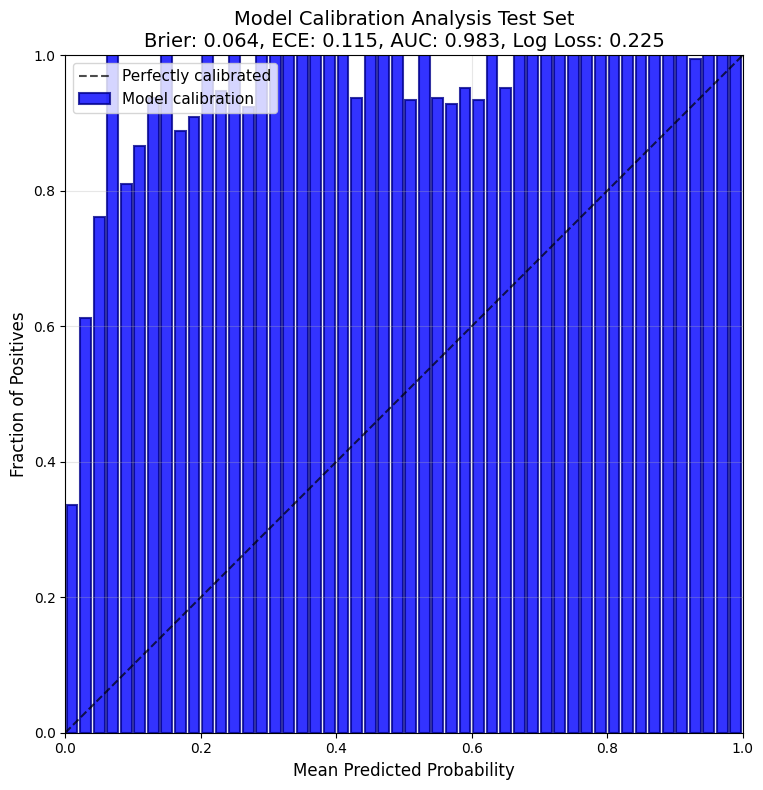


CALIBRATION METRICS:
Brier Score: 0.0641
Expected Calibration Error (ECE): 0.1146
AUC-ROC: 0.9834
Log Loss: 0.2251


ANALYZING VALIDATION SET
Data loaded successfully!
Total samples: 4116
Class distribution: {1: 4012, 0: 104}

Creating calibration plot with 100 bins...
Plot saved to /projects/retprogression/rgarridogarcia/calibration_plots/calibration_plot.png


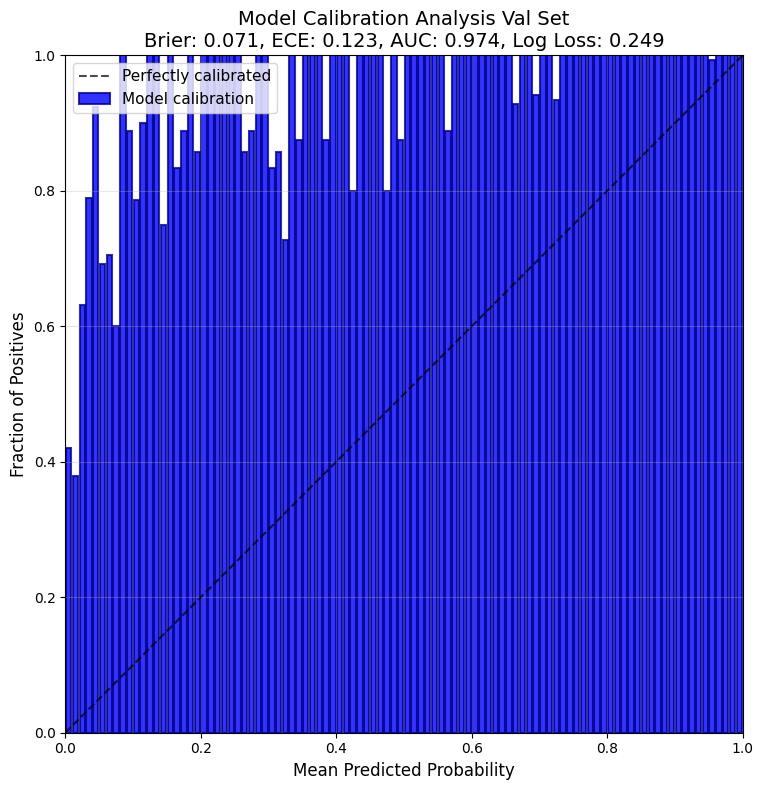


CALIBRATION METRICS:
Brier Score: 0.0708
Expected Calibration Error (ECE): 0.1228
AUC-ROC: 0.9735
Log Loss: 0.2485


ANALYZING COMPLETE SET
Data loaded successfully!
Total samples: 106879
Class distribution: {1: 103260, 0: 3619}

Creating calibration plot with 100 bins...
Plot saved to /projects/retprogression/rgarridogarcia/calibration_plots/calibration_plot.png


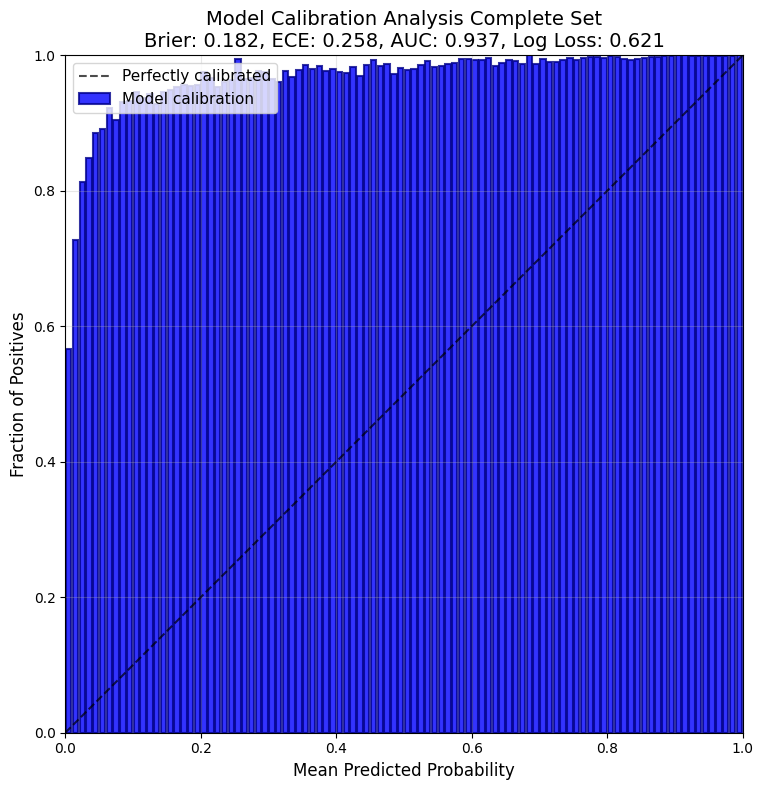


CALIBRATION METRICS:
Brier Score: 0.1817
Expected Calibration Error (ECE): 0.2580
AUC-ROC: 0.9368
Log Loss: 0.6215


COMPARATIVE SUMMARY
Dataset          Brier Score      ECE  AUC-ROC   Log Loss
-------------------------------------------------------
Test Set              0.0641   0.1146   0.9834     0.2251
Validation Set        0.0708   0.1228   0.9735     0.2485
Complete Set          0.1817   0.2580   0.9368     0.6215


In [12]:
test_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/test_results_20250917_085511/predictions_best_balanced_acc_model.csv"
val_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/val_results_20250917_085511/predictions_best_balanced_acc_model.csv"
train_csv_path = "/projects/retprogression/gradable_dr_train.csv"
complete_csv_path = "/projects/retprogression/rgarridogarcia/validation_results_20250917_082610/predictions_best_balanced_acc_model.csv"
output_directory = "/projects/retprogression/rgarridogarcia/calibration_plots"

# Create output directory if it doesn't exist
import os
if output_directory and not os.path.exists(output_directory):
    os.makedirs(output_directory)
    
# Run calibration analysis for all three datasets
print("="*60)
print("ANALYZING TEST SET")
print("="*60)
test_metrics = create_detailed_calibration_analysis(
    test_csv_path, 
    output_directory, 
    title="Model Calibration Analysis Test Set",
    n_bins=50
)

print("\n\n" + "="*60)
print("ANALYZING VALIDATION SET")
print("="*60)
val_metrics = create_detailed_calibration_analysis(
    val_csv_path, 
    output_directory, 
    title="Model Calibration Analysis Val Set",
    n_bins=100
)

print("\n\n" + "="*60)
print("ANALYZING COMPLETE SET")
print("="*60)
complete_metrics = create_detailed_calibration_analysis(
    complete_csv_path, 
    output_directory, 
    title="Model Calibration Analysis Complete Set",
    n_bins=100
)

# Optional: Compare metrics across all sets
print("\n\n" + "="*60)
print("COMPARATIVE SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'Brier Score':>12} {'ECE':>8} {'AUC-ROC':>8} {'Log Loss':>10}")
print("-"*55)
print(f"{'Test Set':<15} {test_metrics['brier_score']:>12.4f} {test_metrics['ece']:>8.4f} {test_metrics['auc_roc']:>8.4f} {test_metrics['log_loss']:>10.4f}")
print(f"{'Validation Set':<15} {val_metrics['brier_score']:>12.4f} {val_metrics['ece']:>8.4f} {val_metrics['auc_roc']:>8.4f} {val_metrics['log_loss']:>10.4f}")
print(f"{'Complete Set':<15} {complete_metrics['brier_score']:>12.4f} {complete_metrics['ece']:>8.4f} {complete_metrics['auc_roc']:>8.4f} {complete_metrics['log_loss']:>10.4f}")